In [1]:
import os
import shutil
import json
import subprocess

os.environ["JAVA_HOME"] = r"C:\Progra~1\Java\jdk-17.0.5"
os.environ["HADOOP_HOME"] = r"C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2"
os.environ["HADOOP_HOME_DIR"] = os.environ["HADOOP_HOME"]

import pyspark
SPARK_HOME = os.path.dirname(pyspark.__file__)
os.environ["SPARK_HOME"] = SPARK_HOME

os.environ["PATH"] = (
    os.environ["JAVA_HOME"] + r"\bin;"
    + os.environ["HADOOP_HOME"] + r"\bin;"
    + os.environ["HADOOP_HOME"] + r"\sbin;"
    + SPARK_HOME + r"\bin;"
    + os.environ["PATH"]
)

print("Java:", shutil.which("java"))
print("PySpark:", pyspark.__version__)
print("SPARK_HOME:", SPARK_HOME)
print("HADOOP_HOME:", os.environ["HADOOP_HOME"])
print("winutils exists:", os.path.exists(os.path.join(os.environ["HADOOP_HOME"], "bin", "winutils.exe")))

Java: C:\Progra~1\Java\jdk-17.0.5\bin\java.EXE
PySpark: 4.2.0
SPARK_HOME: C:\Users\user\anaconda3\envs\ahs2024\Lib\site-packages\pyspark
HADOOP_HOME: C:\Users\user\Downloads\hadoop-3.4.2.tar\hadoop-3.4.2
winutils exists: True


## 2. Verify HDFS Dataset

In [3]:
HADOOP_CMD = os.path.join(
    os.environ["HADOOP_HOME"],
    "bin",
    "hdfs.cmd"
)

HDFS_DATASET = "hdfs://localhost:9000/group4/exorde_dataset"

result = subprocess.run(
    [HADOOP_CMD, "dfs", "-ls", "/group4/exorde_dataset"],
    capture_output=True,
    text=True,
    shell=True
)

print(result.stdout)
print("HDFS dataset path:", HDFS_DATASET)

Found 10 items
drwxr-xr-x   - user supergroup          0 2026-09-30 20:22 /group4/exorde_dataset/.cache
-rw-r--r--   1 user supergroup  126700482 2026-09-30 20:22 /group4/exorde_dataset/processed_data_10.parquet
-rw-r--r--   1 user supergroup  122354391 2026-09-30 20:22 /group4/exorde_dataset/processed_data_102.parquet
-rw-r--r--   1 user supergroup  123734841 2026-09-30 20:22 /group4/exorde_dataset/processed_data_104.parquet
-rw-r--r--   1 user supergroup  125530815 2026-09-30 20:23 /group4/exorde_dataset/processed_data_105.parquet
-rw-r--r--   1 user supergroup  128716168 2026-09-30 20:23 /group4/exorde_dataset/processed_data_108.parquet
-rw-r--r--   1 user supergroup  122385693 2026-09-30 20:23 /group4/exorde_dataset/processed_data_114.parquet
-rw-r--r--   1 user supergroup  123994516 2026-09-30 20:23 /group4/exorde_dataset/processed_data_12.parquet
-rw-r--r--   1 user supergroup  118763518 2026-09-30 20:23 /group4/exorde_dataset/processed_data_122.parquet
-rw-r--r--   1 user superg

## 3. Kafka Producer – Send Dataset Records

In [5]:
from kafka import KafkaProducer
import pyarrow.parquet as pq

HDFS_FILE = "/group4/exorde_dataset/processed_data_10.parquet"
LOCAL_FILE = "processed_data_10.parquet"
KAFKA_SERVER = "localhost:9092"
TOPIC = "sentiment_data"

producer = KafkaProducer(
    bootstrap_servers=KAFKA_SERVER,
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

print("Reading dataset file from HDFS...")

subprocess.run(
    [
        HADOOP_CMD,
        "dfs",
        "-get",
        HDFS_FILE,
        LOCAL_FILE
    ],
    check=True,
    shell=True
)

table = pq.read_table(LOCAL_FILE)
rows = table.to_pylist()

print("Records loaded:", len(rows))

for row in rows[:100]:
    producer.send(TOPIC, row)

producer.flush()
producer.close()

print("100 dataset records sent successfully to Kafka.")

Reading dataset file from HDFS...
Records loaded: 498432
100 dataset records sent successfully to Kafka.


## 4. Kafka Consumer – Verify Incoming Messages

In [7]:
from kafka import KafkaConsumer

consumer = KafkaConsumer(
    TOPIC,
    bootstrap_servers=KAFKA_SERVER,
    auto_offset_reset="earliest",
    consumer_timeout_ms=5000,
    value_deserializer=lambda x: json.loads(x.decode("utf-8"))
)

count = 0

for message in consumer:
    if count < 5:
        print(message.value)
    count += 1

consumer.close()

print("Messages read from Kafka:", count)

{'test': 'hello'}
{'date': '2024-12-01T09:31:08.000Z', 'original_text': 'I don’t think you understand the meaning of urgent.\n\n$700k in a high yield (not so high anymore) savings is still earning more than what it would have prior to announcement of raising interest rates in 03/2022.\n\nIt’s not like it fell from 5% to 1%, or even 2%.\n\nThat’s to say, you have time and it’s not urgent. \n\nDon’t know what to do with the cash and vested rsu? Start with the wiki (sidebar) and possibly consult with a really good cpa. Not enough information and quite possibly more of a circle jerk post than anything.', 'url': 'https://www.reddit.com/r/personalfinance/comments/1h3zhjm/advice_on_these_2_urgent_decisions_to_make/lzukqt7/', 'author_hash': None, 'language': 'en', 'primary_theme': 'Economy', 'english_keywords': 'meaning, raising interest, urgent, yield, anymore, high anymore, announcement, rates, vested, raising, fell, high, interest, not, rsu, start, high yield, interest rates, understand, si

## 5. Start Spark with Kafka Connector

In [9]:
from pyspark.sql import SparkSession

project_dir = os.getcwd()

jars = [
    os.path.join(project_dir, "spark-sql-kafka-0-10_2.13-4.2.0.jar"),
    os.path.join(project_dir, "kafka-clients-3.9.2.jar"),
    os.path.join(project_dir, "spark-token-provider-kafka-0-10_2.13-4.2.0.jar"),
    os.path.join(project_dir, "scala-parallel-collections_2.13-1.2.0.jar"),
    os.path.join(project_dir, "jsr305-3.0.0.jar"),
    os.path.join(project_dir, "commons-pool2-2.13.1.jar")
]

missing_jars = [j for j in jars if not os.path.exists(j)]
if missing_jars:
    raise FileNotFoundError("Missing Spark/Kafka JARs:\n" + "\n".join(missing_jars))

spark = SparkSession.builder \
    .appName("Group4SentimentAnalysis") \
    .master("local[*]") \
    .config("spark.jars", ",".join(jars)) \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark with Kafka connector started successfully")

Spark version: 4.2.0
Spark with Kafka connector started successfully


## 6. Kafka Data Schema

In [11]:
from pyspark.sql.functions import from_json, col, when, trim, lit
from pyspark.sql.types import (
    StructType, StructField, StringType,
    DoubleType, ArrayType, IntegerType
)

schema = StructType([
    StructField("date", StringType(), True),
    StructField("original_text", StringType(), True),
    StructField("url", StringType(), True),
    StructField("author_hash", StringType(), True),
    StructField("language", StringType(), True),
    StructField("primary_theme", StringType(), True),
    StructField("english_keywords", StringType(), True),
    StructField("sentiment", DoubleType(), True),
    StructField("main_emotion", StringType(), True),
    StructField("secondary_themes", ArrayType(IntegerType()), True)
])

print("Kafka JSON schema created successfully")

Kafka JSON schema created successfully


## 7. Kafka Batch Verification

In [13]:
kafka_df = spark.read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", KAFKA_SERVER) \
    .option("subscribe", TOPIC) \
    .option("startingOffsets", "earliest") \
    .load()

print("Kafka connection successful")
print("Kafka records:", kafka_df.count())

kafka_df.selectExpr(
    "CAST(value AS STRING) AS value"
).show(5, truncate=False)

Kafka connection successful
Kafka records: 404
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [14]:
parsed_df = kafka_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

clean_df = parsed_df.filter(
    col("sentiment").isNotNull()
)

print("Valid records:", clean_df.count())
clean_df.show(5, truncate=50)

Valid records: 403
+------------------------+--------------------------------------------------+--------------------------------------------------+-----------+--------+-------------+--------------------------------------------------+---------+------------+----------------+
|                    date|                                     original_text|                                               url|author_hash|language|primary_theme|                                  english_keywords|sentiment|main_emotion|secondary_themes|
+------------------------+--------------------------------------------------+--------------------------------------------------+-----------+--------+-------------+--------------------------------------------------+---------+------------+----------------+
|2024-12-01T09:31:08.000Z|I don’t think you understand the meaning of urg...|https://www.reddit.com/r/personalfinance/commen...|       NULL|      en|      Economy|meaning, raising interest, urgent, yield, anymo...|  

## 8. Step 3 – PySpark Structured Streaming

In [16]:
stream_df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", KAFKA_SERVER) \
    .option("subscribe", TOPIC) \
    .option("startingOffsets", "earliest") \
    .load()

parsed_stream_df = stream_df.select(
    from_json(
        col("value").cast("string"),
        schema
    ).alias("data")
).select("data.*")

clean_stream_df = parsed_stream_df.filter(
    col("sentiment").isNotNull()
)

print("Structured Streaming pipeline created successfully")
print("Streaming:", clean_stream_df.isStreaming)

Structured Streaming pipeline created successfully
Streaming: True


### Step 3 – Feature Engineering

In [18]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

stream_tokenizer = Tokenizer(
    inputCol="original_text",
    outputCol="words"
)

stream_hashingTF = HashingTF(
    inputCol="words",
    outputCol="rawFeatures",
    numFeatures=10000
)

stream_features_df = stream_hashingTF.transform(
    stream_tokenizer.transform(clean_stream_df)
)

print("Streaming feature engineering created successfully")
print("Streaming:", stream_features_df.isStreaming)

Streaming feature engineering created successfully
Streaming: True


In [19]:
stream_query = stream_features_df.writeStream \
    .format("console") \
    .outputMode("append") \
    .option("truncate", False) \
    .option("numRows", 5) \
    .start()

print("Structured Streaming query started successfully")
print("Query active:", stream_query.isActive)

Structured Streaming query started successfully
Query active: True


In [20]:
print("Streaming query active:", stream_query.isActive)
print("Status:", stream_query.status)

Streaming query active: True
Status: {'message': 'Initializing sources', 'isDataAvailable': False, 'isTriggerActive': False}


### Streaming Test Message

In [22]:
test_message = {
    "date": "2026-10-02T13:00:00Z",
    "original_text": "I really love this project, it is amazing!",
    "url": "test",
    "author_hash": "test_user",
    "language": "en",
    "primary_theme": "Technology",
    "english_keywords": "love, project, amazing",
    "sentiment": 0.90,
    "main_emotion": "joy",
    "secondary_themes": [1]
}

test_producer = KafkaProducer(
    bootstrap_servers=KAFKA_SERVER,
    value_serializer=lambda v: json.dumps(v).encode("utf-8")
)

test_producer.send(TOPIC, test_message).get(timeout=10)
test_producer.close()

print("New Kafka streaming test message sent successfully")

New Kafka streaming test message sent successfully


In [23]:
import time

time.sleep(5)

print("Streaming query active:", stream_query.isActive)
print("Recent progress:")
print(stream_query.recentProgress)

Streaming query active: True
Recent progress:
[{
    "id": "2d96f60d-b151-40d2-a54e-3cd8de1cf9fc",
    "runId": "1e991c5b-84b7-4b6c-a1f7-a262857dfb1b",
    "name": null,
    "timestamp": "2026-10-02T13:28:35.898Z",
    "batchId": 0,
    "batchDuration": 4283,
    "numInputRows": 405,
    "inputRowsPerSecond": 0.0,
    "processedRowsPerSecond": 94.6,
    "durationMs": {
        "addBatch": 2081,
        "commitOffsets": 532,
        "getBatch": 20,
        "latestOffset": 877,
        "queryPlanning": 190,
        "triggerExecution": 4277,
        "walCommit": 547
    },
    "stateOperators": [],
    "sources": [
        {
            "description": "KafkaV2[Subscribe[sentiment_data]]",
            "startOffset": null,
            "endOffset": {
                "sentiment_data": {
                    "0": 405
                }
            },
            "latestOffset": {
                "sentiment_data": {
                    "0": 405
                }
            },
            "numInp

In [24]:
stream_query.stop()
print("Streaming query stopped successfully")

Streaming query stopped successfully


## 9. Sentiment Labeling

In [26]:
labeled_df = clean_df.withColumn(
    "sentiment_label",
    when(col("sentiment") < 0, "Negative")
    .otherwise("Positive")
)

labeled_df.select(
    "sentiment",
    "sentiment_label"
).show(20)

distribution = labeled_df.groupBy("sentiment_label").count()
distribution.show()

+---------+---------------+
|sentiment|sentiment_label|
+---------+---------------+
|     0.58|       Positive|
|     0.02|       Positive|
|      0.5|       Positive|
|    -0.33|       Negative|
|     0.42|       Positive|
|    -0.31|       Negative|
|    -0.07|       Negative|
|    -0.46|       Negative|
|     0.74|       Positive|
|     0.16|       Positive|
|     0.42|       Positive|
|     -0.5|       Negative|
|     0.19|       Positive|
|     -0.5|       Negative|
|     0.17|       Positive|
|      0.7|       Positive|
|     0.02|       Positive|
|    -0.45|       Negative|
|     0.54|       Positive|
|     0.75|       Positive|
+---------+---------------+
only showing top 20 rows
+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|       Positive|  252|
|       Negative|  152|
+---------------+-----+



## 10. Full Dataset from HDFS

In [28]:
full_df = spark.read.parquet(HDFS_DATASET)

print("Full dataset records:", full_df.count())
full_df.printSchema()

Full dataset records: 4475224
root
 |-- date: string (nullable = true)
 |-- original_text: string (nullable = true)
 |-- url: string (nullable = true)
 |-- author_hash: string (nullable = true)
 |-- language: string (nullable = true)
 |-- primary_theme: string (nullable = true)
 |-- english_keywords: string (nullable = true)
 |-- sentiment: double (nullable = true)
 |-- main_emotion: string (nullable = true)
 |-- secondary_themes: array (nullable = true)
 |    |-- element: long (containsNull = true)



In [29]:
full_labeled_df = full_df.withColumn(
    "sentiment_label",
    when(col("sentiment") < 0, "Negative")
    .otherwise("Positive")
)

full_distribution = full_labeled_df.groupBy(
    "sentiment_label"
).count()

full_distribution.show()

+---------------+-------+
|sentiment_label|  count|
+---------------+-------+
|       Positive|2564821|
|       Negative|1910403|
+---------------+-------+



## 11. Step 4 – MLlib Prediction Modeling

In [31]:
ml_df = full_labeled_df.select(
    "original_text",
    "sentiment_label"
).sample(
    withReplacement=False,
    fraction=0.02,
    seed=42
)

print("ML records:", ml_df.count())
ml_df.groupBy("sentiment_label").count().show()

ml_train_df, ml_test_df = ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("ML training records:", ml_train_df.count())
print("ML testing records:", ml_test_df.count())

ML records: 89590
+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|       Positive|51228|
|       Negative|38362|
+---------------+-----+

ML training records: 71906
ML testing records: 17684


### TF-IDF Feature Engineering for ML

In [33]:
ml_tokenizer = Tokenizer(
    inputCol="original_text",
    outputCol="words"
)

ml_hashingTF = HashingTF(
    inputCol="words",
    outputCol="rawFeatures",
    numFeatures=10000
)

ml_idf = IDF(
    inputCol="rawFeatures",
    outputCol="features"
)

ml_train_words = ml_tokenizer.transform(ml_train_df)
ml_test_words = ml_tokenizer.transform(ml_test_df)

ml_train_tf = ml_hashingTF.transform(ml_train_words)
ml_test_tf = ml_hashingTF.transform(ml_test_words)

ml_idf_model = ml_idf.fit(ml_train_tf)

ml_train_features = ml_idf_model.transform(ml_train_tf)
ml_test_features = ml_idf_model.transform(ml_test_tf)

print("ML TF-IDF transformation completed successfully")

ML TF-IDF transformation completed successfully


### Logistic Regression

In [35]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StringIndexer

ml_label_indexer = StringIndexer(
    inputCol="sentiment_label",
    outputCol="label"
)

label_model = ml_label_indexer.fit(ml_train_features)

ml_train_labeled = label_model.transform(ml_train_features)
ml_test_labeled = label_model.transform(ml_test_features)

ml_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

ml_lr_model = ml_lr.fit(ml_train_labeled)

print("ML Logistic Regression model trained successfully")

ML Logistic Regression model trained successfully


In [36]:
ml_predictions = ml_lr_model.transform(ml_test_labeled)

print("Predictions generated successfully")
print("Test records:", ml_predictions.count())

ml_predictions.select(
    "sentiment_label",
    "label",
    "prediction"
).show(10)

Predictions generated successfully
Test records: 17684
+---------------+-----+----------+
|sentiment_label|label|prediction|
+---------------+-----+----------+
|       Positive|  0.0|       0.0|
|       Positive|  0.0|       1.0|
|       Positive|  0.0|       0.0|
|       Negative|  1.0|       0.0|
|       Positive|  0.0|       0.0|
|       Positive|  0.0|       1.0|
|       Positive|  0.0|       0.0|
|       Positive|  0.0|       1.0|
|       Positive|  0.0|       0.0|
|       Positive|  0.0|       0.0|
+---------------+-----+----------+
only showing top 10 rows


## 12. Model Evaluation

In [38]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

ml_accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(ml_predictions)

ml_precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(ml_predictions)

ml_recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(ml_predictions)

ml_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(ml_predictions)

print("Accuracy :", round(ml_accuracy * 100, 2), "%")
print("Precision:", round(ml_precision * 100, 2), "%")
print("Recall   :", round(ml_recall * 100, 2), "%")
print("F1 Score :", round(ml_f1 * 100, 2), "%")

Accuracy : 69.45 %
Precision: 69.2 %
Recall   : 69.45 %
F1 Score : 69.19 %


In [39]:
ml_confusion_matrix = ml_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
)

ml_confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0| 7797|
|  0.0|       1.0| 2324|
|  1.0|       0.0| 3079|
|  1.0|       1.0| 4484|
+-----+----------+-----+



## 13. Visualizations

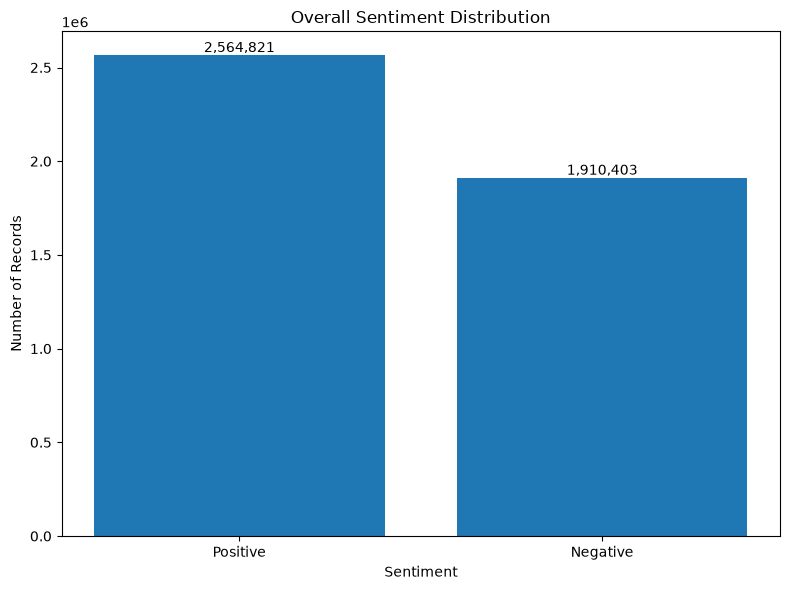

In [41]:
import matplotlib.pyplot as plt

full_distribution_pd = full_distribution.toPandas()

plt.figure(figsize=(8, 6))
plt.bar(
    full_distribution_pd["sentiment_label"],
    full_distribution_pd["count"]
)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Records")

for i, value in enumerate(full_distribution_pd["count"]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(
    "overall_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

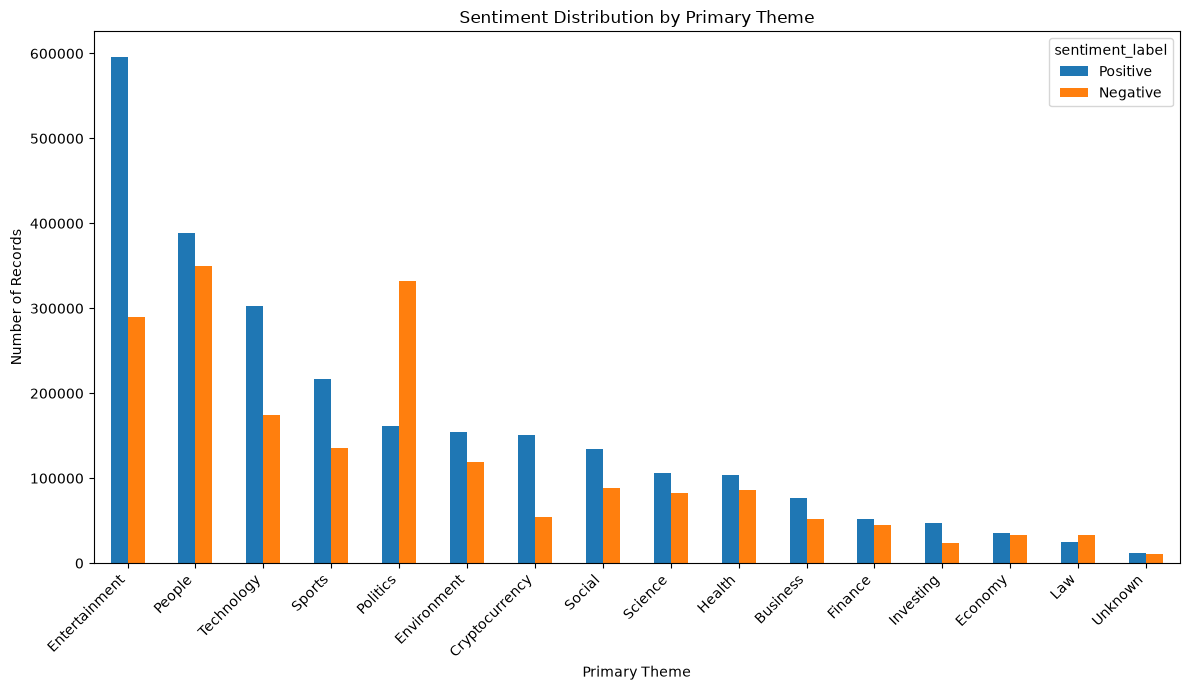

In [42]:
theme_summary = full_labeled_df.withColumn(
    "theme",
    when(
        col("primary_theme").isNull() | (trim(col("primary_theme")) == ""),
        "Unknown"
    ).otherwise(col("primary_theme"))
).groupBy(
    "theme",
    "sentiment_label"
).count()

theme_plot = theme_summary.toPandas()

pivot_theme = theme_plot.pivot(
    index="theme",
    columns="sentiment_label",
    values="count"
).fillna(0)

for sentiment in ["Positive", "Negative"]:
    if sentiment not in pivot_theme.columns:
        pivot_theme[sentiment] = 0

pivot_theme = pivot_theme.sort_values(
    by="Positive",
    ascending=False
)

ax = pivot_theme[["Positive", "Negative"]].plot(
    kind="bar",
    figsize=(12, 7)
)

ax.set_title("Sentiment Distribution by Primary Theme")
ax.set_xlabel("Primary Theme")
ax.set_ylabel("Number of Records")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "sentiment_by_theme.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

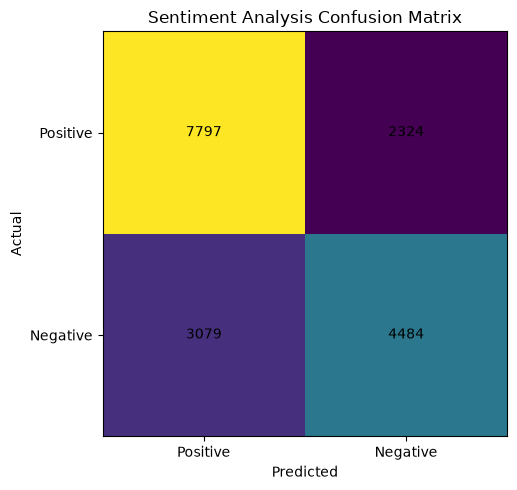

In [43]:
cm = [
    [7797, 2324],
    [3079, 4484]
]

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Sentiment Analysis Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Positive", "Negative"])
plt.yticks([0, 1], ["Positive", "Negative"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.tight_layout()
plt.savefig(
    "sentiment_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## CONNECT PYTHON WITH MYSQL

In [45]:
pip install mysql

Note: you may need to restart the kernel to use updated packages.


In [46]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [47]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="sentiment_analysis",
    port=3306
)

print("MySQL connection successful")

MySQL connection successful


In [48]:
cursor = connection.cursor()

cursor.execute("SHOW TABLES")

print("Tables in sentiment_analysis:")
for table in cursor:
    print(table[0])

Tables in sentiment_analysis:
sentiment_results


In [83]:
print("full_labeled_df:", "full_labeled_df" in globals())
print("ml_predictions:", "ml_predictions" in globals())

full_labeled_df: True
ml_predictions: True


In [85]:
mysql_df = ml_predictions.select(
    "sentiment_label",
    "prediction"
)

mysql_df.show(5)

+---------------+----------+
|sentiment_label|prediction|
+---------------+----------+
|       Positive|       0.0|
|       Positive|       1.0|
|       Positive|       0.0|
|       Negative|       0.0|
|       Positive|       0.0|
+---------------+----------+
only showing top 5 rows


In [87]:
mysql_df = ml_predictions.select(
    "original_text",
    "sentiment_label",
    "prediction"
)

mysql_df.printSchema()

root
 |-- original_text: string (nullable = true)
 |-- sentiment_label: string (nullable = false)
 |-- prediction: double (nullable = false)



In [89]:
mysql_rows = mysql_df.collect()

print("Rows ready for MySQL:", len(mysql_rows))
print("First row:", mysql_rows[0])

Rows ready for MySQL: 17684
First row: Row(original_text='\nAww man, I can’t upload more than one pic! I’ll list what I ordered, below.\n\nFor me:\n- Dr. Dennis Gross Skincare Alpha Beta® Daily Peel Vault (I plan on sharing this with my mom)\n- Moroccanoil Dry Shampoo Light Tones\n- SEPHORA COLLECTION Hydrating Hand Mask in Coconut + Mango\n- Drunk Elephant Lippe Balm\n\nFor my bestie, who will be spending Christmas with me this year:\n- KAYALI Discovery Perfume Layering Set\n- SEPHORA COLLECTION Set of 8 Face &amp; Body Masks\n- I’m still working on her gifts, but figured this is a good start!\n\nFor my mom:\n- SEPHORA COLLECTION Hydrating Hand Mask in Mango', sentiment_label='Positive', prediction=0.0)


In [95]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="sentiment_analysis",
    port=3306
)

cursor = connection.cursor()

print("MySQL reconnected successfully")

MySQL reconnected successfully


In [103]:
cursor.execute("SELECT COUNT(*) FROM sentiment_results")
count = cursor.fetchone()[0]

print("Records currently in MySQL:", count)

Records currently in MySQL: 0


In [105]:
insert_query = """
INSERT INTO sentiment_results
(original_text, sentiment_label, prediction)
VALUES (%s, %s, %s)
"""

batch_size = 100
total_inserted = 0

for i in range(0, len(mysql_rows), batch_size):
    batch = mysql_rows[i:i + batch_size]

    insert_data = [
        (
            row["original_text"],
            row["sentiment_label"],
            "Positive" if row["prediction"] == 0.0 else "Negative"
        )
        for row in batch
    ]

    cursor.executemany(insert_query, insert_data)
    connection.commit()

    total_inserted += len(batch)

    if total_inserted % 1000 == 0 or total_inserted == len(mysql_rows):
        print("Inserted:", total_inserted)

print("Total records inserted:", total_inserted)

Inserted: 1000
Inserted: 2000
Inserted: 3000
Inserted: 4000
Inserted: 5000
Inserted: 6000
Inserted: 7000
Inserted: 8000
Inserted: 9000
Inserted: 10000
Inserted: 11000
Inserted: 12000
Inserted: 13000
Inserted: 14000
Inserted: 15000
Inserted: 16000
Inserted: 17000
Inserted: 17684
Total records inserted: 17684


In [107]:
cursor.execute("SELECT COUNT(*) FROM sentiment_results")
count = cursor.fetchone()[0]

print("Total records in MySQL:", count)

Total records in MySQL: 17684


In [111]:
pip install django 

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 480.1 kB/s eta 0:00:17
   -- ------------------------------------- 0.5/8.4 MB 480.1 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.4 MB 578.7 kB/s eta 0:00:14
   ---- ----------------------------------- 1.0/8.4 MB 613.9 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/8.4 MB 613.9 kB/s eta 0:00:13
   ------ --------------------------------- 1.3/8.4 MB 651.7 kB/s eta 0:00:11
   ------- -------------------------------- 1.6/8

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import django

print("Django version:", django.get_version())

Django version: 6.1.1
